In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RESULTS_DIR = Path("../results")

In [2]:
rows = []
for f in sorted(RESULTS_DIR.glob("*_models.json")):
    with open(f) as fh:
        entries = json.load(fh)
    # Older files may wrap the list in a dict; handle both shapes.
    if isinstance(entries, dict):
        entries = entries.get("models", [])
    for e in entries:
        rows.append({"notebook": f.stem.split("_")[0], **e})

res = pd.DataFrame(rows)
res["label"] = res["model"] + " (" + res["notes"].fillna("—") + ")"
ranked = res.sort_values("gini", ascending=False)

print(f"{len(res)} entries loaded from {res['notebook'].nunique()} notebooks")
ranked[["notebook", "model", "notes", "auc", "gini", "ap"]]

17 entries loaded from 4 notebooks


,notebook,model,notes,auc,gini,ap
5,01,XGBoost,without calc,0.642300,0.284600,0.068300
10,03,CatBoost,"hold-out, with calc (5-fold CV: gini 0.2818)",0.641600,0.283300,0.068500
4,01,XGBoost,with calc,0.641300,0.282500,0.067600
7,01,Stacking,without calc,0.640900,0.281900,0.068200
15,04,Weighted Average (XGBoost + SVM),Weighted averaging ensemble; weights selected ...,0.640445,0.280890,0.065069
16,04,Stacking (XGBoost + SVM),Stacking ensemble with Logistic Regression as ...,0.640438,0.280876,0.064852
6,01,Stacking,with calc,0.640300,0.280700,0.067700
12,04,XGBoost,"Non-weighted XGBoost; Original AP Rank 2, sele...",0.639774,0.279547,0.066740
14,04,Simple Average (XGBoost + SVM),Simple averaging ensemble; weights fixed at 50...,0.638405,0.276810,0.063611
2,01,Random Forest,with calc,0.634500,0.268900,0.064800


### Model Comparison : 

In [3]:
res["label"] = res["model"] + " (" + res["notes"].fillna("—") + ")"
ranked = res.sort_values("gini", ascending=False)
print(ranked[["notebook", "model", "notes", "gini"]].to_string(index=False))

notebook                            model                                                                                         notes     gini
      01                          XGBoost                                                                                  without calc 0.284600
      03                         CatBoost                                                  hold-out, with calc (5-fold CV: gini 0.2818) 0.283300
      01                          XGBoost                                                                                     with calc 0.282500
      01                         Stacking                                                                                  without calc 0.281900
      04 Weighted Average (XGBoost + SVM)                  Weighted averaging ensemble; weights selected using development OOF ROC-AUC. 0.280890
      04         Stacking (XGBoost + SVM)      Stacking ensemble with Logistic Regression as meta-model; final evaluation on test 

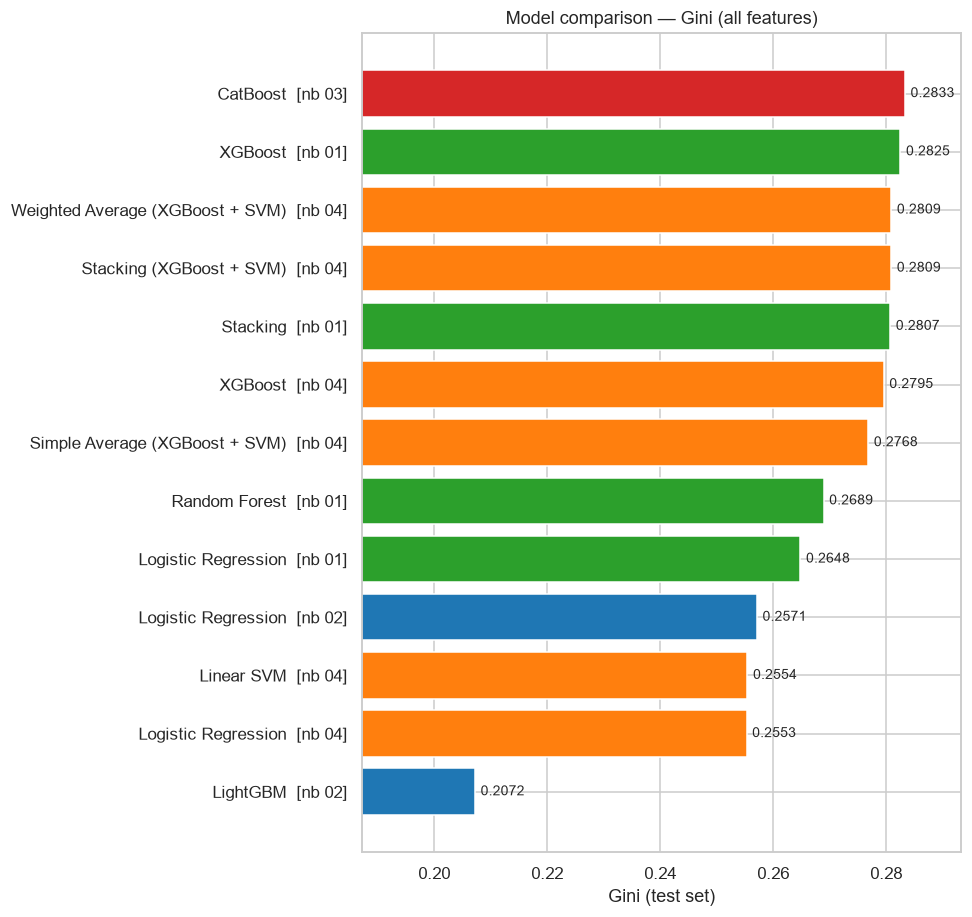

In [8]:
with_calc = ranked[
    (
        ranked["notes"].str.contains("with calc", na=False)
        & ~ranked["notes"].str.contains("without", na=False)
    )
    |
    (
        ranked["notebook"] == "04"
    )
]

top = with_calc.sort_values("gini")
nb_codes, _ = pd.factorize(top["notebook"])
palette = plt.cm.tab10(np.linspace(0, 1, 10))
colors = [palette[c % 10] for c in nb_codes]

plt.figure(figsize=(9, 0.5 * len(top) + 2))
plt.barh(top["model"] + "  [nb " + top["notebook"] + "]", top["gini"],
         color=colors)
plt.xlabel("Gini (test set)")
plt.xlim(top["gini"].min() - 0.02, top["gini"].max() + 0.01)
plt.title("Model comparison — Gini (all features)")
plt.grid(True, axis="x", zorder=-3)

for i, v in enumerate(top["gini"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Best Model : 

In [5]:
best = ranked.iloc[0]
print(f"Best model: {best['model']}  (notebook {best['notebook']}, {best['notes']})")
print(f"  AUC  {best['auc']:.4f}")
print(f"  Gini {best['gini']:.4f}")
if pd.notna(best["ap"]):
    print(f"  AP   {best['ap']:.4f}  ({best['ap']/best['base_rate']:.2f}x base rate)")
print("\nParameters:")
for k, v in best["params"].items():
    print(f"  {k}: {v}")

Best model: XGBoost  (notebook 01, without calc)
  AUC  0.6423
  Gini 0.2846
  AP   0.0683  (1.88x base rate)

Parameters:
  subsample: 1.0
  reg_lambda: 1
  reg_alpha: 5
  n_estimators: 1600
  min_child_weight: 100
  max_depth: 5
  learning_rate: 0.01
  colsample_bytree: 0.6
